# <p align = "center"> Looking at ccp4 sub types </p>

In [1]:
# Initialize notebook
from pathlib import Path
import sys
sys.path.insert( 0, Path("../../.."))

## Getting Required Data into Object

In [ ]:
# Getting file with .ccp4 files info
from xaidar.filesUtils import loadPickle, savePyObj
import re
from pathlib import Path

objStoreContent = {}
for bucket in ["pandda", "xchem"]:
    print( f"Loading Bucket {bucket} ")
    ccp4Files = {}
    fileTypesDir = Path(f"../../../data/s3Sizes/{bucket}/raw")
    for frag in list(fileTypesDir.iterdir())[:1]:
        print( f"Loading fragment file: {frag.name}")
        if frag.is_file:
            fileTypes = loadPickle( frag )
            for objKey, size in list(fileTypes.items()):
                if re.search( "\.ccp4$", objKey):
                    fileName = objKey.split("/")[-1]
                    ccp4Files[objKey] = ( fileName, size )

    objStoreContent[bucket] = ccp4Files

savePath = Path( "../../../data/s3Sizes/ccp4Files.pkl")
savePyObj( objStoreContent, savePath )

In [2]:
from pathlib import Path
from xaidar.filesUtils import loadPickle
result = loadPickle(Path( "../../../data/s3Sizes/ccp4Files.pkl") )

In [3]:
objStoreContent = {"pandda": None, "xchem": None }

## xchem Bucket

In [5]:
# Looking at xchem first


print("result[\"xchem\"].keys():\n\t",list( result["xchem"].keys() )[:5] )
print("result[\"xchem\"].values():\n\t",list( result["xchem"].values() )[:5] )
lstCcp4Names = list( zip( *list(  result["xchem"].values() ) ) ) 
print("\nLength of lstCcp4Names: ", len(lstCcp4Names))
print( "\nNumber of Names: ",len( lstCcp4Names[0]),"\nNumber of Sizes: ", len( lstCcp4Names[1]))
print(  "\nNames Example: ", lstCcp4Names[0][:3], "\nSizes Example: ",  lstCcp4Names[1][:3])


length = len( result["xchem"] )
totalSize = sum( lstCcp4Names[1] )
totalSize_GB = round( totalSize / (1e9), 3)
print( f"\nNumber of ccp4 files in xchem: { length}" )
print( f"Space taken by ccp4 files in xchem: {totalSize_GB} GB")
# print( lstCcp4Names[:2])

result["xchem"].keys():
	 ['data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-aligned-map.ccp4', 'data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-difference-from-mean.ccp4', 'data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-event_1_occupancy_1.0_map.ccp4', 'data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-event_1_occupancy_1.0_map.native.ccp4', 'data/2015/lb13320-1/processing/analysis/backup/pandda/interesting_datasets/SHH-x1009/SHH-x1009-observed.native.ccp4']
result["xchem"].values():
	 [('SHH-x1009-aligned-map.ccp4', 7367488), ('SHH-x1009-difference-from-mean.ccp4', 7367488), ('SHH-x1009-event_1_occupancy_1.0_map.ccp4', 7367488), ('SHH-x1009-event_1_occupancy_1.0_map.native.ccp4', 7367488), ('SHH-x1009-observed.native.ccp4', 7367488)]

Length of lstCcp4Names:  2

Number of Names:  2007939 
Number of Si

In [27]:
# Scrolling through file names to identify regex pattern
num = 5
for i in range( 200000, 200100): #  len(lstCcp4Names[0]) // num
    print(lstCcp4Names[0][i*num : (i+1)*num] )


('SOCS2A-x0577-event_19_1-BDC_0.11_map.native.ccp4', 'SOCS2A-x0577-event_17_1-BDC_0.2_map.native.ccp4', 'SOCS2A-x0577-event_16_1-BDC_0.14_map.native.ccp4', 'SOCS2A-x0577-event_15_1-BDC_0.14_map.native.ccp4', 'SOCS2A-x0577-event_12_1-BDC_0.32_map.native.ccp4')
('SOCS2A-x0577-event_22_1-BDC_0.42_map.native.ccp4', 'SOCS2A-x0577-event_1_1-BDC_0.25_map.native.ccp4', 'SOCS2A-x0577-event_24_1-BDC_0.25_map.native.ccp4', 'SOCS2A-x0577-event_21_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x0577-event_26_1-BDC_0.09_map.native.ccp4')
('SOCS2A-x0577-event_27_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x0577-event_29_1-BDC_0.09_map.native.ccp4', 'SOCS2A-x0577-event_23_1-BDC_0.26_map.native.ccp4', 'SOCS2A-x0577-event_20_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x0577-event_25_1-BDC_0.26_map.native.ccp4')
('SOCS2A-x0577-event_13_1-BDC_0.09_map.native.ccp4', 'SOCS2A-x0577-event_2_1-BDC_0.25_map.native.ccp4', 'SOCS2A-x0577-event_31_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x0577-event_34_1-BDC_0.05_map.native.ccp4', 'SOCS2A-x05

In [6]:
# Saving identified Regex Expressions
lst_regexs = [ "-aligned-map\.ccp4$",
              "difference-from-mean\.ccp4$",
              
              "-event_[0-9]+_occupancy_.+_map\.ccp4$",
              "-event_[0-9]+_occupancy_.+_map\.native\.ccp4$",
              
              "-event_.+-BDC_.+_map\.ccp4$",
              "-event_.+-BDC_.+_map\.native\.ccp4$",
              
              "-observed\.native.ccp4$",
              
              "-z_map\.ccp4$",
              "z_map.native.ccp4$", 

              "_mask.ccp4", #  'total_mask.ccp4' 'protein_mask.ccp4' 'symmetry_mask.ccp4 "z_mask\.ccp4$
              "_app\.ccp4$",
              "truncated\.ccp4$",
              "cut\.ccp4$",
              "[0-9]_[0-9][0-9][0-9]\.ccp4$", # 1_766.ccp4
              "_native\.ccp4$", # 2_native.ccp4
              "_[0-9]+_mean\.ccp4$", # '2.7399910858949643_1_mean.ccp4'
              "_mov.ccp4$",  # 2.7399910858949643_STAG1A-x0138_mov.ccp4'
              "_ref.ccp4$", # 2.7399910858949643_STAG1A-x0234_ref.ccp4

]
print( f"Created \"lst_regexs\"")

Created "lst_regexs"


In [ ]:
# For each regex, get list of matching objKeys, names, and sizes

from xaidar.filesUtils import loadPickle
import re


ccp4Subtypes = { regex : [] for regex in lst_regexs }
missingSubtypes = [] #  List of the name of .ccp4 files that do not match any of the regex expressions expressed in lst_regex

# num = 100

for objKey, name , size in zip( list( result["xchem"].keys() ),  lstCcp4Names[0],  lstCcp4Names[1]): #zip( list( result["xchem"].keys() )[:num],  lstCcp4Names[0][:num],  lstCcp4Names[1][:num]):
    match = False
    for regex in lst_regexs:
        if re.search( regex, name):
            match = True
            ccp4Subtypes[regex].append( (objKey, name , size) )

    if not match: missingSubtypes.append( (objKey, name, size) )
print( "Created \"ccp4Subtypes\" & \"missingSubtypes\"" )

# Estimated Time: 20 s

Created "ccp4Subtypes" & "missingSubtypes"


In [8]:
# Count size for each ccp4 subtype and save in the first element of ccp4Subtypes[subtype] 
for regex in ccp4Subtypes.keys():
    *_, sizes  =  list( zip( *ccp4Subtypes[regex] ) ) 
    totalSize = sum(sizes)
    ccp4Subtypes[regex].insert(0, totalSize)

print( "Updated \"ccp4Subtypes\"")

Updated "ccp4Subtypes"


In [9]:
# Order ccp4 subttypes keys based of storage usage
lst_keys = list(ccp4Subtypes.keys())
lst_sizes = [ value[0] for _ , value in  ccp4Subtypes.items()]
together = zip( lst_keys, lst_sizes)
ordered_keys = sorted( together, key = lambda item: item[1])
ordered_keys, _ = zip( *ordered_keys)
print( "Created \"ordered_keys\"")

Created "ordered_keys"


In [32]:
# Get Sizes of each ccp4 subtype
allRegex =  list( ordered_keys[::-1]  )
allSizes = [  ccp4Subtypes[regex][0] for regex in ordered_keys[::-1]  ]


print( f"File Size(GB)   \tPercentage  \tFiles Count \tPercentage \tRegex ")

length = len( result["xchem"] )
totalSize = sum( lstCcp4Names[1] )
totalSize_GB = round( totalSize / (1e9), 3)

allRegex += ["Total"]
allSizes += [totalSize]

print( f"{totalSize_GB}\t\t\t\t{length}\t\t\t\tTotal")


for regex in ordered_keys[::-1]:
    percentage = round(len(ccp4Subtypes[regex][1:]) / length, 2)
    gbSize = round( ccp4Subtypes[regex][0] / ( 1e9), 3)
    percentageSize = round( gbSize / totalSize_GB, 2)
    print( f"{gbSize}   \t\t{percentageSize}%\t\t{len(ccp4Subtypes[regex][1:])}\t\t- {percentage} % - \t{regex}")

# Get values for ccp4 subtypes that were not identified through regex
percentage = round(len(missingSubtypes) / length, 2)
*_, sizes  =  list( zip( *missingSubtypes) ) 
totalSize = sum(sizes)
gbSize = round( totalSize/ ( 1e9), 3)
percentageSize = round( gbSize / totalSize_GB, 2)
print(f"{gbSize}\t\t{percentageSize}%\t\t{len(missingSubtypes)}  \t- {percentage} % -\tOthers")

allRegex += ["Others"]
allSizes += [totalSize]

objStoreContent["xchem"] = { key : value for key, value in zip( allRegex, allSizes)}

File Size(GB)   	Percentage  	Files Count 	Percentage 	Regex 
43335.564				2007939				Total
19587.449   		0.45%		691467		- 0.34 % - 	-event_.+-BDC_.+_map\.native\.ccp4$
5558.125   		0.13%		233957		- 0.12 % - 	_app\.ccp4$
5122.429   		0.12%		221266		- 0.11 % - 	z_map.native.ccp4$
3058.339   		0.07%		81968		- 0.04 % - 	-event_.+-BDC_.+_map\.ccp4$
1519.839   		0.04%		137644		- 0.07 % - 	truncated\.ccp4$
1142.12   		0.03%		48531		- 0.02 % - 	-z_map\.ccp4$
427.799   		0.01%		30161		- 0.02 % - 	difference-from-mean\.ccp4$
427.799   		0.01%		30161		- 0.02 % - 	-aligned-map\.ccp4$
327.773   		0.01%		18546		- 0.01 % - 	[0-9]_[0-9][0-9][0-9]\.ccp4$
186.005   		0.0%		10672		- 0.01 % - 	_ref.ccp4$
135.314   		0.0%		7755		- 0.0 % - 	_native\.ccp4$
81.615   		0.0%		4675		- 0.0 % - 	_[0-9]+_mean\.ccp4$
74.356   		0.0%		6555		- 0.0 % - 	-event_[0-9]+_occupancy_.+_map\.native\.ccp4$
67.989   		0.0%		5943		- 0.0 % - 	-event_[0-9]+_occupancy_.+_map\.ccp4$
41.25   		0.0%		4585		- 0.0 % - 	_mask.ccp4
20.75

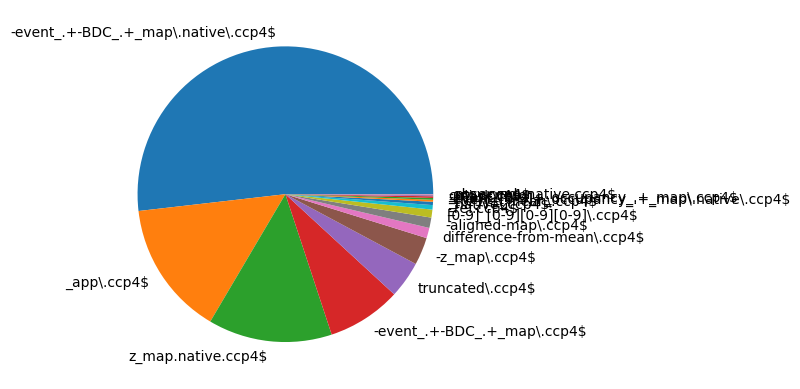

In [10]:
# Plot the Results into a Pie Chart
import matplotlib.pyplot as plt

sizes = [ ccp4Subtypes[regex][0] for regex in ordered_keys[::-1] ]

fig = plt.figure( )

plt.pie(sizes, labels = ordered_keys[::-1]  )

plt.show()

## pandda Bucket

In [33]:
# Looking at pandda first

bucket = "pandda"
print("result[\"pandda\"].keys():\n\t",list( result["pandda"].keys() )[:5] )
lstCcp4Names = list( zip( *list(  result["pandda"].values() ) ) ) 
print("\nLength of lstCcp4Names: ", len(lstCcp4Names))
print( "\nNumber of Names: ",len( lstCcp4Names[0]),"\nNumber of Sizes: ", len( lstCcp4Names[1]))
print(  "\nNames Example: ", lstCcp4Names[0][:3], "\nSizes Example: ",  lstCcp4Names[1][:3])


length = len( result["pandda"] )
totalSize = sum( lstCcp4Names[1] )
totalSize_GB = round( totalSize / (1e9), 3)
print( f"\nNumber of ccp4 files in pandda: { length}" )
print( f"Space taken by ccp4 files in pandda: {totalSize_GB} GB")
# print( lstCcp4Names[:2])

result["pandda"].keys():
	 ['PlProwt/processed_datasets/PlProwt-x0222/PlProwt-x0222-z_map.native.ccp4', 'PlProwt/processed_datasets/PlProwt-x0221/0/truncated.ccp4', 'PlProwt/processed_datasets/PlProwt-x0223/0/cut.ccp4', 'PlProwt/processed_datasets/PlProwt-x0221/PlProwt-x0221-z_map.native.ccp4', 'PlProwt/processed_datasets/PlProwt-x0221/1/truncated.ccp4']

Length of lstCcp4Names:  2

Number of Names:  900842 
Number of Sizes:  900842

Names Example:  ('PlProwt-x0222-z_map.native.ccp4', 'truncated.ccp4', 'cut.ccp4') 
Sizes Example:  (10078800, 8959056, 54696)

Number of ccp4 files in pandda: 900842
Space taken by ccp4 files in pandda: 7791.653 GB


In [34]:
# Scrolling through file names to identify regex pattern
num = 5
for i in range( 20000, 20100): #  len(lstCcp4Names[0]) // num
    print(lstCcp4Names[0][i*num : (i+1)*num] )


('truncated.ccp4', 'truncated.ccp4', 'LmARS-x0021-event_13_1-BDC_0.0_map.native.ccp4', 'LmARS-x0021-event_15_1-BDC_0.04_map.native.ccp4', 'LmARS-x0020-event_16_1-BDC_0.29_map.native.ccp4')
('LmARS-x0021-event_16_1-BDC_0.25_map.native.ccp4', 'LmARS-x0021-event_14_1-BDC_0.19_map.native.ccp4', 'LmARS-x0021-event_10_1-BDC_0.0_map.native.ccp4', 'LmARS-x0021-event_17_1-BDC_0.16_map.native.ccp4', 'truncated.ccp4')
('LmARS-x0020-event_28_1-BDC_0.54_map.native.ccp4', 'LmARS-x0021-event_20_1-BDC_0.44_map.native.ccp4', 'LmARS-x0021-event_11_1-BDC_0.19_map.native.ccp4', 'truncated.ccp4', 'truncated.ccp4')
('LmARS-x0021-event_21_1-BDC_0.57_map.native.ccp4', 'LmARS-x0021-event_29_1-BDC_0.41_map.native.ccp4', 'LmARS-x0021-event_22_1-BDC_0.54_map.native.ccp4', 'LmARS-x0021-event_26_1-BDC_0.4_map.native.ccp4', 'cut.ccp4')
('LmARS-x0021-event_28_1-BDC_0.83_map.native.ccp4', 'LmARS-x0021-event_24_1-BDC_0.59_map.native.ccp4', 'LmARS-x0021-event_27_1-BDC_0.95_map.native.ccp4', 'LmARS-x0021-event_37_1-BDC_0

In [39]:
# Saving identified Regex Expressions
lst_regexs = [ 
              "z_map\.native\.ccp4$",
              "-event_.+-BDC_.+_map\.native\.ccp4$",
              "truncated\.ccp4$",
              "cut\.ccp4$",
]

#             "-aligned-map\.ccp4$",
#               "difference-from-mean\.ccp4$",
              
#               "-event_[0-9]+_occupancy_.+_map\.ccp4$",
#               "-event_[0-9]+_occupancy_.+_map\.native\.ccp4$",
              
#               "-event_.+-BDC_.+_map\.ccp4$",
              
#               "-observed\.native.ccp4$",
              
#               "-z_map\.ccp4$",
#               "z_map.native.ccp4$", 

#               "_mask.ccp4", #  'total_mask.ccp4' 'protein_mask.ccp4' 'symmetry_mask.ccp4 "z_mask\.ccp4$
#               "_app\.ccp4$",

#               "[0-9]_[0-9][0-9][0-9]\.ccp4$", # 1_766.ccp4
#               "_native\.ccp4$", # 2_native.ccp4
#               "_[0-9]+_mean\.ccp4$", # '2.7399910858949643_1_mean.ccp4'
#               "_mov.ccp4$",  # 2.7399910858949643_STAG1A-x0138_mov.ccp4'
#               "_ref.ccp4$", # 2.7399910858949643_STAG1A-x0234_ref.ccp4

# ]
print( f"Created \"lst_regexs\"")

Created "lst_regexs"


In [40]:
# For each regex, get list of matching objKeys, names, and sizes

from xaidar.filesUtils import loadPickle
import re


ccp4Subtypes = { regex : [] for regex in lst_regexs }
missingSubtypes = [] #  List of the name of .ccp4 files that do not match any of the regex expressions expressed in lst_regex

num = 100

for objKey, name , size in zip( list( result["pandda"].keys() ),  lstCcp4Names[0],  lstCcp4Names[1]): #zip( list( result["pandda"].keys() )[:num],  lstCcp4Names[0][:num],  lstCcp4Names[1][:num]):
    match = False
    for regex in lst_regexs:
        if re.search( regex, name):
            match = True
            ccp4Subtypes[regex].append( (objKey, name , size) )

    if not match: missingSubtypes.append( (objKey, name, size) )
    
print( "Created \"ccp4Subtypes\" & \"missingSubtypes\"" )

Created "ccp4Subtypes" & "missingSubtypes"


In [37]:
for key, value in ccp4Subtypes.items():
    print( len(value), key)

print( len( missingSubtypes))

34133 z_map\.native\.ccp4$
412329 -event_.+-BDC_.+_map\.native\.ccp4$
227204 truncated\.ccp4$
227176 cut\.ccp4$
0


In [41]:
if len( missingSubtypes) != 0:
    _ , missingNames, _ = list( zip( *missingSubtypes))
    num = 5
    for i in range( 2000, 2100): #  len(lstCcp4Names[0]) // num
        print(missingNames[i*num : (i+1)*num] )

In [42]:
# Count size for each ccp4 subtype and save in the first element of ccp4Subtypes[subtype] 
for regex in ccp4Subtypes.keys():
    *_, sizes  =  list( zip( *ccp4Subtypes[regex] ) ) 
    totalSize = sum(sizes)
    ccp4Subtypes[regex].insert(0, totalSize)

print( "Updated \"ccp4Subtypes\"")

Updated "ccp4Subtypes"


In [43]:
# Order ccp4 subttypes keys based of storage usage
lst_keys = list(ccp4Subtypes.keys())
lst_sizes = [ value[0] for _ , value in  ccp4Subtypes.items()]
together = zip( lst_keys, lst_sizes)
ordered_keys = sorted( together, key = lambda item: item[1])
ordered_keys, _ = zip( *ordered_keys)
print( "Created \"ordered_keys\"")

Created "ordered_keys"


In [44]:
# Get Sizes of each ccp4 subtype
allRegex =  list( ordered_keys[::-1]  )
allSizes = [  ccp4Subtypes[regex][0] for regex in ordered_keys[::-1]  ]

print( f"File Size(GB)   \tPercentage  \tFiles Count \tPercentage \tRegex ")

length = len( result["pandda"] )
totalSize = sum( lstCcp4Names[1] )
totalSize_GB = round( totalSize / (1e9), 3)

allRegex += ["Total"]
allSizes += [totalSize]

print( f"{totalSize_GB}\t\t\t\t{length}\t\t\t\tTotal")

for regex in ordered_keys[::-1]:
    percentage = round(len(ccp4Subtypes[regex][1:]) / length, 2)
    gbSize = round( ccp4Subtypes[regex][0] / ( 1e9), 3)
    percentageSize = round( gbSize / totalSize_GB, 2)
    print( f"{gbSize}   \t\t{percentageSize}%\t\t{len(ccp4Subtypes[regex][1:])}\t\t- {percentage} % - \t{regex}")

# Get values for ccp4 subtypes that were not identified through regex
if len(missingSubtypes) != 0:
    percentage = round(len(missingSubtypes) / length, 2)
    *_, sizes  =  list( zip( *missingSubtypes) ) 
    totalSize = sum(sizes)
    gbSize = round( totalSize/ ( 1e9), 3)
    percentageSize = round( gbSize / totalSize_GB, 2)

    allRegex += ["Others"]
    allSizes += [totalSize]

    print(f"{gbSize}\t\t{percentageSize}%\t\t{len(missingSubtypes)}  \t- {percentage} % -\tOthers")

objStoreContent["pandda"] = { key : value for key, value in zip( allRegex, allSizes)}

File Size(GB)   	Percentage  	Files Count 	Percentage 	Regex 
7791.653				900842				Total
4723.007   		0.61%		412329		- 0.46 % - 	-event_.+-BDC_.+_map\.native\.ccp4$
2633.538   		0.34%		227204		- 0.25 % - 	truncated\.ccp4$
424.112   		0.05%		34133		- 0.04 % - 	z_map\.native\.ccp4$
10.995   		0.0%		227176		- 0.25 % - 	cut\.ccp4$


In [ ]:
# Pie Plot 



## Plot the values for both buckets



import matplotlib.pyplot as plt
 
fig, ax = plt.subplits

In [38]:
from pathlib import Path
import pandas as pd

df = pd.read_csv( Path( "./ccp4subtypes.csv") )





In [39]:
display( df.head() )

,File Size(GB),Percentage,Files Count,Percentage.1,Regex
0,43335.564,NaN,2007939,NaN,Total
1,19587.449,0.45%,691467,- 0.34 % -,-event_.+-BDC_.+_map\.native\.ccp4$
2,5558.125,0.13%,233957,- 0.12 % -,_app\.ccp4$
3,5122.429,0.12%,221266,- 0.11 % -,z_map.native.ccp4$
4,3058.339,0.07%,81968,- 0.04 % -,-event_.+-BDC_.+_map\.ccp4$


In [40]:
from copy import deepcopy
oldLabels = list( df.columns)
newLabels = deepcopy(oldLabels)
newLabels[1] = "Percentage Size"
newLabels[-2] = "Percentage Count"
print( f"Old Labels: {oldLabels}\nNew Labels: {newLabels}")
df.columns = newLabels

Old Labels: ['File Size(GB)', 'Percentage', 'Files Count', 'Percentage.1', 'Regex']
New Labels: ['File Size(GB)', 'Percentage Size', 'Files Count', 'Percentage Count', 'Regex']


In [41]:
print( set( [ type( value) for value in df["Percentage Count"]] ) )
print( [ value for value in df["Percentage Count"] if type(value) == str ][:5] ) 
print( [ value for value in df["Percentage Count"] if type(value) == float ][:5] ) 

{<class 'str'>, <class 'float'>}
['- 0.34 % - ', '- 0.12 % - ', '- 0.11 % - ', '- 0.04 % - ', '- 0.07 % - ']
[nan]


In [42]:
df["Percentage Size"] = df["Percentage Size"].apply( lambda x: float(x[:-1]) if type( x) == str else x )

In [43]:
df["Percentage Count"] = df["Percentage Count"].apply( lambda x: float(x[2:6]) if type( x) == str else x )

In [64]:
df =  df.iloc[ : , [-1, 0,1,2,3] ]

In [65]:
display( df.head()  )

,Regex,File Size(GB),Percentage Size,Files Count,Percentage Count
0,Total,43335.564,NaN,2007939,NaN
1,-event_.+-BDC_.+_map\.native\.ccp4$,19587.449,0.45,691467,0.34
2,_app\.ccp4$,5558.125,0.13,233957,0.12
3,z_map.native.ccp4$,5122.429,0.12,221266,0.11
4,-event_.+-BDC_.+_map\.ccp4$,3058.339,0.07,81968,0.04


In [66]:
df.to_csv( Path( "./ccp4subtypes.csv") , index = False)